# BrushCue Example: Old Money Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/old_money_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/old-money-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


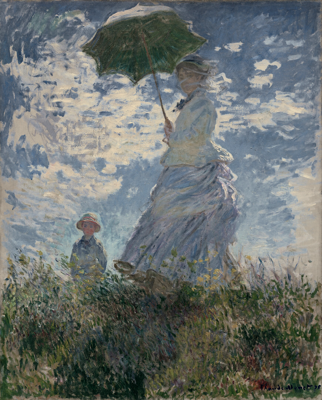

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
graded = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.01, 0.05, c);\nlet skin = band(h, 0.9, 0.45);\nlet blue = band(h, 4.45, 1.0) * colorful * amount;\nlet camel = band(h, 1.3, 0.9) * colorful * (1.0 - skin) * amount;\nlet green = band(h, 2.55, 0.9) * colorful * amount;\nlet h2 = h + 0.08 * blue + 0.15 * green + (1.22 - h) * 0.45 * camel;\nlet c2 = c * (1.0 - 0.15 * amount) * (1.0 - 0.3 * blue) * (1.0 - 0.4 * camel) * (1.0 - 0.3 * green);\nvar l = input.x - 0.5 * c * amount - 0.07 * blue - 0.06 * green;\nlet s_curve = l * l * (3.0 - 2.0 * l);\nl = mix(l, s_curve, 0.25 * amount);\nlet hi = smoothstep(0.65, 1.0, l);\nl = l - 0.06 * hi * hi * amount;\nlet a = c2 * cos(h2) + 0.003 * hi * amount;\nlet b = c2 * sin(h2) + 0.022 * hi * amount;\nreturn vec4<f32>(l, a, b, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
textured = graded.film_grain((0.7 * strength), 300.0, 0.7, 150.0, 0.3, 600.0, 0.0)
bounds = input_image.bounds()
graph = textured.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
